In [2]:
# Cell 1: imports and project paths

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

from scipy.stats import ks_2samp, entropy  # for KS & JS

import shap

# project paths (same idea as previous notebook)
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_DIR = PROJECT_ROOT / "data"
RAW_TITANIC_DIR = DATA_DIR / "raw" / "titanic"

print("Project root:", PROJECT_ROOT)
print("Raw Titanic data dir:", RAW_TITANIC_DIR)


c:\Users\surbhi.prasad\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: C:\Users\surbhi.prasad\Documents\Projects\mlops_ai_monitoring
Raw Titanic data dir: C:\Users\surbhi.prasad\Documents\Projects\mlops_ai_monitoring\data\raw\titanic


In [3]:
# Cell 2: load Titanic train data and basic preprocessing

train_path = RAW_TITANIC_DIR / "train.csv"
df = pd.read_csv(train_path)

print("Shape:", df.shape)
df.head()


Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Cell 2b: basic preprocessing

# Keep a subset of useful features
FEATURE_COLS = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
TARGET_COL = "Survived"

data = df[FEATURE_COLS + [TARGET_COL]].copy()

# Handle missing values
data["Age"] = data["Age"].fillna(data["Age"].median())
data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])

# One-hot encode categorical variables
data_encoded = pd.get_dummies(
    data,
    columns=["Sex", "Embarked"],
    drop_first=True,
)

X = data_encoded.drop(TARGET_COL, axis=1)
y = data_encoded[TARGET_COL]

print("Encoded feature columns:", X.columns.tolist())
X.head()


Encoded feature columns: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


In [5]:
# Cell 3: create reference vs current splits (simulated time)

n = len(X)
split_idx = n // 2

X_ref = X.iloc[:split_idx].copy()
y_ref = y.iloc[:split_idx].copy()

X_cur = X.iloc[split_idx:].copy()
y_cur = y.iloc[split_idx:].copy()

print("Reference size:", X_ref.shape[0])
print("Current size  :", X_cur.shape[0])


Reference size: 445
Current size  : 446


In [6]:
# Cell 4: train a RandomForest model on reference period (same model used everywhere)

X_train, X_val, y_train, y_val = train_test_split(
    X_ref, y_ref, test_size=0.2, random_state=42, stratify=y_ref
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)

y_val_pred = rf_model.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)

print(f"Validation accuracy on reference: {val_acc:.4f}")
print("\nClassification report (reference validation):")
print(classification_report(y_val, y_val_pred))


Validation accuracy on reference: 0.8427

Classification report (reference validation):
              precision    recall  f1-score   support

           0       0.86      0.89      0.87        54
           1       0.82      0.77      0.79        35

    accuracy                           0.84        89
   macro avg       0.84      0.83      0.83        89
weighted avg       0.84      0.84      0.84        89



In [7]:
# Cell 5: predictions and probabilities for reference vs current

# Use the SAME model everywhere (assignment requirement)
y_ref_pred = rf_model.predict(X_ref)
y_ref_proba = rf_model.predict_proba(X_ref)[:, 1]  # probability of Survived=1

y_cur_pred = rf_model.predict(X_cur)
y_cur_proba = rf_model.predict_proba(X_cur)[:, 1]

print("Reference predicted mean (Survived=1 prob):", y_ref_proba.mean())
print("Current   predicted mean (Survived=1 prob):", y_cur_proba.mean())


Reference predicted mean (Survived=1 prob): 0.399143316553904
Current   predicted mean (Survived=1 prob): 0.373014530357317


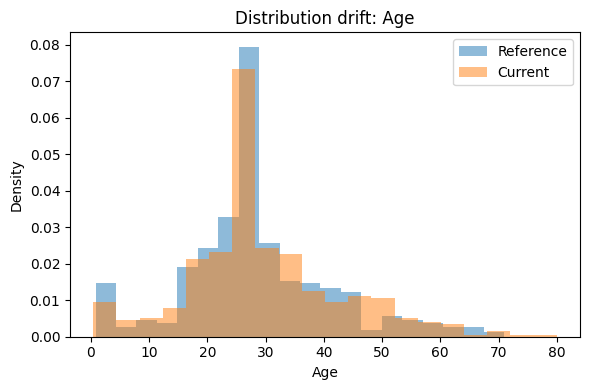

In [8]:
# Cell 6: histogram comparison function for numeric features

NUMERIC_FEATURES = ["Pclass", "Age", "SibSp", "Parch", "Fare"]

def plot_numeric_feature_drift(df_ref, df_cur, feature, bins=20):
    plt.figure(figsize=(6, 4))
    plt.hist(
        df_ref[feature],
        bins=bins,
        alpha=0.5,
        density=True,
        label="Reference",
    )
    plt.hist(
        df_cur[feature],
        bins=bins,
        alpha=0.5,
        density=True,
        label="Current",
    )
    plt.title(f"Distribution drift: {feature}")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example: plot drift for Age
plot_numeric_feature_drift(data.iloc[:split_idx], data.iloc[split_idx:], "Age")


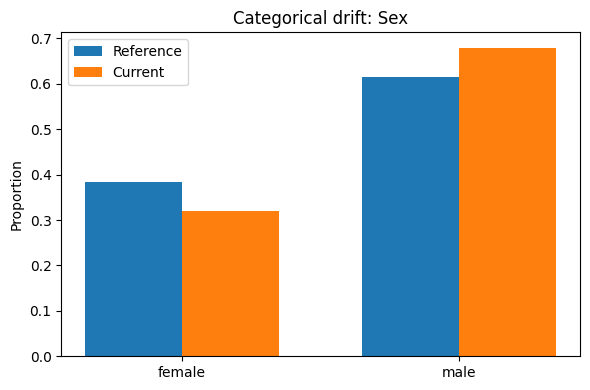

In [9]:
# Cell 7: bar plots for categorical features

CATEGORICAL_FEATURES = ["Sex", "Embarked"]

def plot_categorical_feature_drift(df_ref, df_cur, feature):
    plt.figure(figsize=(6, 4))

    ref_counts = df_ref[feature].value_counts(normalize=True).sort_index()
    cur_counts = df_cur[feature].value_counts(normalize=True).sort_index()

    idx = sorted(set(ref_counts.index).union(cur_counts.index))

    ref_vals = [ref_counts.get(i, 0) for i in idx]
    cur_vals = [cur_counts.get(i, 0) for i in idx]

    x = np.arange(len(idx))
    width = 0.35

    plt.bar(x - width / 2, ref_vals, width, label="Reference")
    plt.bar(x + width / 2, cur_vals, width, label="Current")

    plt.xticks(x, idx)
    plt.ylabel("Proportion")
    plt.title(f"Categorical drift: {feature}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example: plot drift for Sex
plot_categorical_feature_drift(data.iloc[:split_idx], data.iloc[split_idx:], "Sex")


In [10]:
# Cell 8: functions for PSI and JS distance

def psi(ref, cur, bins=10, eps=1e-6):
    """
    Population Stability Index.
    ref, cur: 1D numpy arrays or Series
    """
    ref = pd.Series(ref)
    cur = pd.Series(cur)

    # Use same bin edges for both
    quantiles = np.linspace(0, 1, bins + 1)
    bin_edges = ref.quantile(quantiles).values
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf

    ref_counts, _ = np.histogram(ref, bins=bin_edges)
    cur_counts, _ = np.histogram(cur, bins=bin_edges)

    ref_perc = ref_counts / ref_counts.sum()
    cur_perc = cur_counts / cur_counts.sum()

    # Avoid division by zero
    ref_perc = np.where(ref_perc == 0, eps, ref_perc)
    cur_perc = np.where(cur_perc == 0, eps, cur_perc)

    psi_val = np.sum((ref_perc - cur_perc) * np.log(ref_perc / cur_perc))
    return psi_val


def js_distance(ref, cur, bins=20, eps=1e-12):
    """
    Jensen-Shannon distance between two 1D arrays.
    0 = identical, 1 = very different.
    """
    ref = np.asarray(ref)
    cur = np.asarray(cur)

    min_v = min(ref.min(), cur.min())
    max_v = max(ref.max(), cur.max())
    if min_v == max_v:
        return 0.0

    hist_ref, bin_edges = np.histogram(ref, bins=bins, range=(min_v, max_v), density=True)
    hist_cur, _ = np.histogram(cur, bins=bin_edges, density=True)

    p = hist_ref + eps
    q = hist_cur + eps

    p = p / p.sum()
    q = q / q.sum()

    m = 0.5 * (p + q)
    js = 0.5 * (entropy(p, m) + entropy(q, m))
    return float(np.sqrt(js))  # distance


In [11]:
# Cell 9: compute drift metrics per numeric feature

results = []

ref_df = data.iloc[:split_idx]
cur_df = data.iloc[split_idx:]

for feature in NUMERIC_FEATURES:
    ref_vals = ref_df[feature].values
    cur_vals = cur_df[feature].values

    # KS (numeric only)
    ks_stat, ks_p = ks_2samp(ref_vals, cur_vals)

    # PSI
    psi_val = psi(ref_vals, cur_vals, bins=10)

    # JS distance
    js_val = js_distance(ref_vals, cur_vals, bins=20)

    results.append(
        {
            "feature": feature,
            "ks_stat": ks_stat,
            "ks_p_value": ks_p,
            "psi": psi_val,
            "js_distance": js_val,
        }
    )

drift_metrics_df = pd.DataFrame(results)
drift_metrics_df


,feature,ks_stat,ks_p_value,psi,js_distance
0,Pclass,0.044349,0.744573,0.011001,0.037063
1,Age,0.077795,0.122621,0.037713,0.087376
2,SibSp,0.047851,0.663498,0.010579,0.051461
3,Parch,0.015952,1.000000,0.002705,0.045709
4,Fare,0.046249,0.699401,0.017861,0.094325


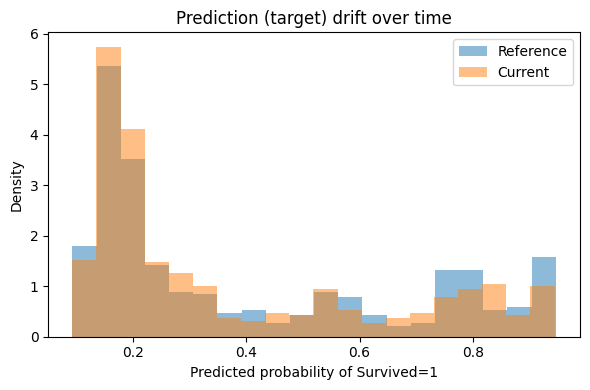

In [13]:
# Cell 10: prediction (target) drift visualization

plt.figure(figsize=(6, 4))
plt.hist(y_ref_proba, bins=20, alpha=0.5, density=True, label="Reference")
plt.hist(y_cur_proba, bins=20, alpha=0.5, density=True, label="Current")
plt.xlabel("Predicted probability of Survived=1")
plt.ylabel("Density")
plt.title("Prediction (target) drift over time")
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
# Cell 11: quantitatively compare prediction distributions

ks_stat_pred, ks_p_pred = ks_2samp(y_ref_proba, y_cur_proba)
psi_pred = psi(y_ref_proba, y_cur_proba, bins=10)
js_pred = js_distance(y_ref_proba, y_cur_proba, bins=20)

print(f"Prediction drift metrics:")
print(f"  KS stat      : {ks_stat_pred:.4f}, p-value={ks_p_pred:.4g}")
print(f"  PSI          : {psi_pred:.4f}")
print(f"  JS distance  : {js_pred:.4f}")


Prediction drift metrics:
  KS stat      : 0.0637, p-value=0.3089
  PSI          : 0.0458
  JS distance  : 0.1154


In [18]:
shap.initjs()

explainer = shap.TreeExplainer(rf_model)

shap_values_all = explainer.shap_values(X)

# Handle different SHAP return types:
if isinstance(shap_values_all, list):
    # Old style: list [class0, class1]
    shap_all_pos = shap_values_all[1]  # positive class
else:
    # New style: array (n_samples, n_features, n_outputs)
    if shap_values_all.ndim == 3:
        # take output index 1 = Survived=1
        shap_all_pos = shap_values_all[:, :, 1]
    else:
        shap_all_pos = shap_values_all  # fallback

print("shap_all_pos shape:", shap_all_pos.shape)  # should be (891, 8)
print("X shape           :", X.shape)

# Split into reference vs current
shap_ref_pos = shap_all_pos[:split_idx]
shap_cur_pos = shap_all_pos[split_idx:]

print("ref SHAP shape:", shap_ref_pos.shape)
print("cur SHAP shape:", shap_cur_pos.shape)

feature_names = X.columns.to_list()

# Now these will be 1D arrays of length n_features
mean_abs_shap_ref = np.abs(shap_ref_pos).mean(axis=0)  # shape (8,)
mean_abs_shap_cur = np.abs(shap_cur_pos).mean(axis=0)  # shape (8,)

print("len(feature_names)     :", len(feature_names))
print("len(mean_abs_shap_ref) :", len(mean_abs_shap_ref))
print("len(mean_abs_shap_cur) :", len(mean_abs_shap_cur))

shap_importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "mean_abs_shap_ref": mean_abs_shap_ref,
        "mean_abs_shap_cur": mean_abs_shap_cur,
    }
)

shap_importance_df.sort_values("mean_abs_shap_ref", ascending=False)


shap_all_pos shape: (891, 8)
X shape           : (891, 8)
ref SHAP shape: (445, 8)
cur SHAP shape: (446, 8)
len(feature_names)     : 8
len(mean_abs_shap_ref) : 8
len(mean_abs_shap_cur) : 8


,feature,mean_abs_shap_ref,mean_abs_shap_cur
5,Sex_male,0.203560,0.197783
0,Pclass,0.055588,0.054875
4,Fare,0.033220,0.035181
1,Age,0.027189,0.029028
2,SibSp,0.018789,0.015915
3,Parch,0.007442,0.006745
7,Embarked_S,0.007391,0.006798
6,Embarked_Q,0.006949,0.005036


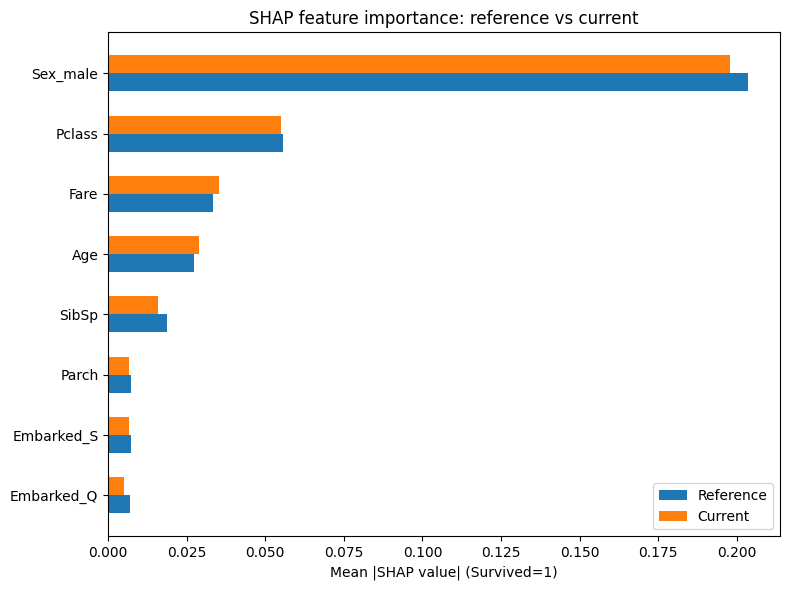

In [20]:
df_imp = shap_importance_df.set_index("feature").sort_values("mean_abs_shap_ref", ascending=True)

plt.figure(figsize=(8, 6))
y_pos = np.arange(len(df_imp))

plt.barh(y_pos - 0.15, df_imp["mean_abs_shap_ref"], height=0.3, label="Reference")
plt.barh(y_pos + 0.15, df_imp["mean_abs_shap_cur"], height=0.3, label="Current")

plt.yticks(y_pos, df_imp.index)
plt.xlabel("Mean |SHAP value| (Survived=1)")
plt.title("SHAP feature importance: reference vs current")
plt.legend()
plt.tight_layout()
plt.show()
